# Long-Short Strategy, Preparing Alpha Factors and Features

## Imports & Settings

In [57]:
import warnings
warnings.filterwarnings('ignore')

In [58]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from talib import RSI, BBANDS, MACD, ATR

In [59]:
MONTH = 21
YEAR = 12 * MONTH

In [60]:
START = '2009-01-01'
END = '2025-04-25'

In [61]:
sns.set_style('darkgrid')
idx = pd.IndexSlice

In [62]:
percentiles = [.001, .01, .02, .03, .04, .05]
percentiles += [1-p for p in percentiles[::-1]]

In [63]:
T = [1, 5, 10, 21, 42, 63]

## Loading Quandl Wiki Stock Prices & Meta Data

In [64]:
DATA_STORE = '../data/nasdaq_data_yf.h5'
ohlcv = ['open', 'close', 'low', 'high', 'volume']
with pd.HDFStore(DATA_STORE) as store:
    prices = (store['nasdaq/price']
              .loc[idx[START:END, :], ohlcv] # select OHLCV columns from 2010 until 2017
              #.rename(columns=lambda x: x.replace('adj_', '')) # simplify column names
              .swaplevel()
              .sort_index())
    metadata = (store['nasdaq/metadata'].loc[:, ['marketcap', 'sector']])


KeyboardInterrupt: 

In [ ]:
prices.sort_index(level='date')

,Price,open,close,low,high,volume
ticker,date,,,,,
AACG,2009-05-06,6.030000,0.453672,5.550000,6.040000,32900.0
AAL,2009-05-06,5.240000,4.713707,4.760000,5.350000,6928400.0
AAME,2009-05-06,0.640000,0.564793,0.640000,0.640000,500.0
AAON,2009-05-06,3.909136,3.511106,3.903210,4.148148,1246894.0
AAPL,2009-05-06,4.761786,3.987403,4.650714,4.767857,473538800.0
...,...,...,...,...,...,...
ZVRA,2025-04-25,7.200000,7.200000,7.040000,7.210000,381300.0
ZVSA,2025-04-25,0.688000,0.701000,0.680000,0.733000,71800.0
ZYBT,2025-04-25,10.100000,10.440000,9.500000,12.460000,599400.0


In [ ]:
metadata

,marketcap,sector
ticker,,
AACB,0.00,
AACBR,0.00,
AACBU,0.00,Finance
AACG,28879805.00,Real Estate
AAL,6411361925.00,Consumer Discretionary
...,...,...
ZVRA,389634257.00,Health Care
ZVSA,1800302.00,Health Care
ZYBT,492416965.00,Health Care


In [ ]:
prices.volume /= 1e3 # make vol figures a bit smaller
prices.index.names = ['symbol', 'date']
metadata.index.name = 'symbol'

## Remove stocks with insufficient observations

We require at least 7 years of data; we simplify and select using both in- and out-of-sample period; please be aware that it would be more accurate to use only the training period to remove data to avoid lookahead bias.

In [ ]:
min_obs = 7 * YEAR
nobs = prices.groupby(level='symbol').size()
keep = nobs[nobs > min_obs].index
prices = prices.loc[idx[keep, :], :]
#prices = prices.loc[prices.index.get_level_values('symbol').isin(keep)]

### Align price and meta data

In [ ]:
metadata = metadata[~metadata.index.duplicated() & metadata.sector.notnull()]
metadata.sector = metadata.sector.str.lower().str.replace(' ', '_')

In [ ]:
shared = (prices.index.get_level_values('symbol').unique()
          .intersection(metadata.index))
metadata = metadata.loc[shared, :]
prices = prices.loc[idx[shared, :], :]

In [ ]:
metadata.marketcap.astype(float).nlargest(1000).index

Index(['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOG', 'GOOGL', 'META', 'TSLA', 'AVGO',
       'NFLX',
       ...
       'MERC', 'EU', 'PNRG', 'ATYR', 'SOHU', 'FSBW', 'MVIS', 'HIVE', 'CZNC',
       'PMTS'],
      dtype='object', name='symbol', length=1000)

### Limit universe to 1,000 stocks with highest market cap

Again, we simplify and use the entire sample period, not just the training period, to select our universe.

In [ ]:
#universe = metadata.marketcap.nlargest(1000).index
universe = metadata.marketcap.astype(float).nlargest(1000).index
prices = prices.loc[idx[universe, :], :]
metadata = metadata.loc[universe]

In [ ]:
metadata.sector.value_counts()

sector
finance                   215
consumer_discretionary    191
technology                188
health_care               188
industrials                88
telecommunications         28
real_estate                26
consumer_staples           25
energy                     19
utilities                  18
miscellaneous               7
basic_materials             5
                            2
Name: count, dtype: int64

In [ ]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3605644 entries, ('AAPL', Timestamp('2009-05-06 00:00:00')) to ('PMTS', Timestamp('2025-04-25 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    3605644 non-null  float64
 1   close   3605644 non-null  float64
 2   low     3605644 non-null  float64
 3   high    3605644 non-null  float64
 4   volume  3605644 non-null  float64
dtypes: float64(5)
memory usage: 151.6+ MB


In [ ]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, AAPL to PMTS
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   marketcap  1000 non-null   object
 1   sector     1000 non-null   object
dtypes: object(2)
memory usage: 23.4+ KB


### Rank assets by Rolling Average Dollar Volume

#### Compute dollar volume

In [ ]:
prices['dollar_vol'] = prices[['close', 'volume']].prod(1).div(1e3)

#### 21-day moving average

In [ ]:
# compute dollar volume to determine universe
dollar_vol_ma = (prices
                 .dollar_vol
                 .unstack('symbol')
                 .rolling(window=21, min_periods=1) # 1 trading month rolling average
                 .mean())

#### Rank stocks by moving average

In [ ]:
prices['dollar_vol_rank'] = (dollar_vol_ma
                            .rank(axis=1, ascending=False)
                            .stack('symbol')
                            .swaplevel())

In [ ]:
#len(prices[prices.dollar_vol_rank < 500].index.get_level_values('symbol'))

In [ ]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3605644 entries, ('AAPL', Timestamp('2009-05-06 00:00:00')) to ('PMTS', Timestamp('2025-04-25 00:00:00'))
Data columns (total 7 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   open             3605644 non-null  float64
 1   close            3605644 non-null  float64
 2   low              3605644 non-null  float64
 3   high             3605644 non-null  float64
 4   volume           3605644 non-null  float64
 5   dollar_vol       3605644 non-null  float64
 6   dollar_vol_rank  3605644 non-null  float64
dtypes: float64(7)
memory usage: 206.6+ MB


## Add some Basic Factors

See [appendix](../24_alpha_factor_library) for details on the below indicators.

### Compute the Relative Strength Index

In [ ]:
def apply_rsi(group, timeperiod=14):
    return pd.Series(RSI(group.values, timeperiod=timeperiod), index=group.index)

In [ ]:
#prices['rsi'] = prices.groupby(level='symbol').close.apply(RSI)
prices['rsi'] = (prices.groupby(level='symbol',group_keys=False).close.
                apply(apply_rsi))

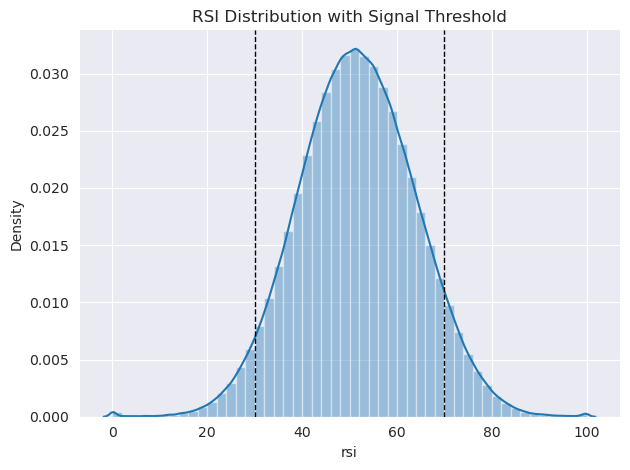

In [ ]:
ax = sns.distplot(prices.rsi.dropna())
ax.axvline(30, ls='--', lw=1, c='k')
ax.axvline(70, ls='--', lw=1, c='k')
ax.set_title('RSI Distribution with Signal Threshold')
sns.despine()
plt.tight_layout()

### Compute Bollinger Bands

In [ ]:
def compute_bb(close):
    high, mid, low = BBANDS(close, timeperiod=20)
    return pd.DataFrame({'bb_high': high, 'bb_low': low}, index=close.index)

In [ ]:
prices = (prices.join(prices
                      .groupby(level='symbol',group_keys=False)
                      .close
                      .apply(compute_bb)))

In [ ]:
prices['bb_high'] = prices.bb_high.sub(prices.close).div(prices.bb_high).apply(np.log1p)
prices['bb_low'] = prices.close.sub(prices.bb_low).div(prices.close).apply(np.log1p)

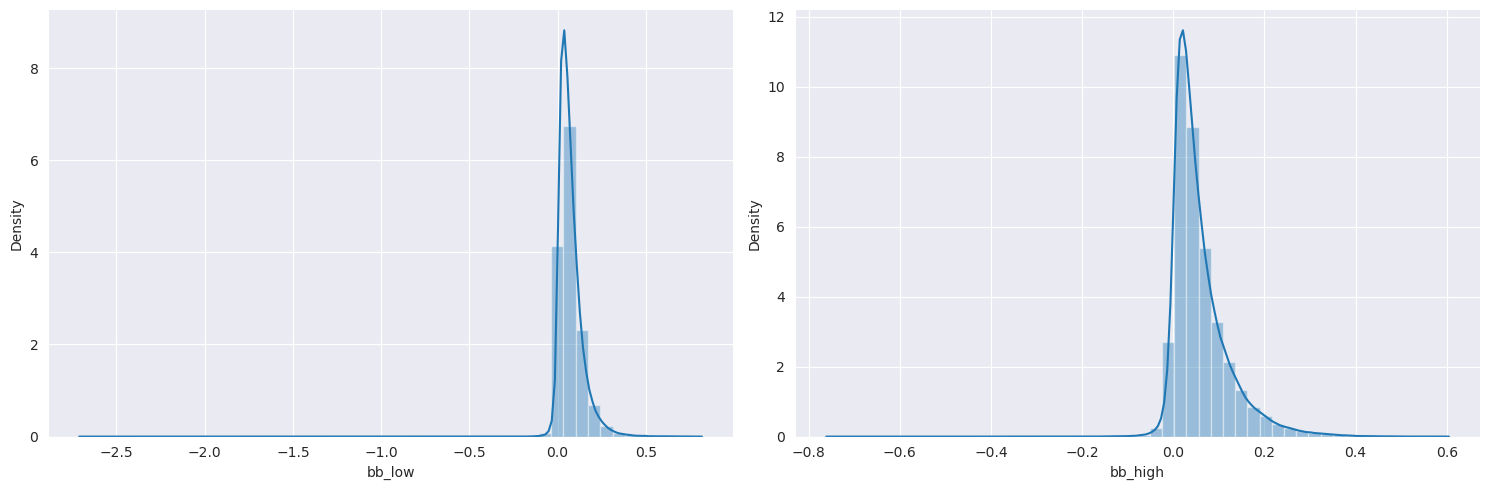

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
sns.distplot(prices.loc[prices.dollar_vol_rank<100, 'bb_low'].dropna(), ax=axes[0])
sns.distplot(prices.loc[prices.dollar_vol_rank<100, 'bb_high'].dropna(), ax=axes[1])
sns.despine()
plt.tight_layout()

### Compute Average True Range

In [ ]:
prices['NATR'] = prices.groupby(level='symbol', 
                                group_keys=False).apply(lambda x: 
                                                        talib.NATR(x.high, x.low, x.close))

In [ ]:
def compute_atr(stock_data):
    df = ATR(stock_data.high, stock_data.low, 
             stock_data.close, timeperiod=14)
    return df.sub(df.mean()).div(df.std())

In [ ]:
prices['ATR'] = (prices.groupby('symbol', group_keys=False)
                 .apply(compute_atr))

### Compute Moving Average Convergence/Divergence

In [ ]:
prices['PPO'] = prices.groupby(level='symbol',group_keys=False).close.apply(talib.PPO)

In [ ]:
def compute_macd(close):
    macd = MACD(close)[0]
    return (macd - np.mean(macd))/np.std(macd)

In [ ]:
prices['MACD'] = (prices
                  .groupby('symbol', group_keys=False)
                  .close
                  .apply(compute_macd))

### Combine Price and Meta Data

In [ ]:
metadata.sector = pd.factorize(metadata.sector)[0].astype(int)
prices = prices.join(metadata[['sector']])

## Compute Returns

### Historical Returns

In [ ]:
by_sym = prices.groupby(level='symbol').close
for t in T:
    prices[f'r{t:02}'] = by_sym.pct_change(t)

### Daily historical return deciles

In [ ]:
for t in T:
    prices[f'r{t:02}dec'] = (prices[f'r{t:02}']
                             .groupby(level='date',group_keys=False)
                             .apply(lambda x: pd.qcut(x, 
                                                      q=10, 
                                                      labels=False, 
                                                      duplicates='drop')))

### Daily sector return deciles

In [ ]:
for t in T:
    prices[f'r{t:02}q_sector'] = (prices
                                  .groupby(['date', 'sector'])[f'r{t:02}']
                                  .transform(lambda x: pd.qcut(x, 
                                                               q=5, 
                                                               labels=False, 
                                                               duplicates='drop')))

### Compute Forward Returns

In [ ]:
for t in [1, 5, 21]:
    prices[f'r{t:02}_fwd'] = prices.groupby(level='symbol')[f'r{t:02}'].shift(-t)

## Remove outliers

In [ ]:
prices[[f'r{t:02}' for t in T]].describe()

,r01,r05,r10,r21,r42,r63
count,3.604644e+06,3.600644e+06,3.595644e+06,3.584644e+06,3.563644e+06,3.542644e+06
mean,1.000122e-03,4.786646e-03,9.240837e-03,1.898768e-02,3.743009e-02,5.635562e-02
std,1.433638e-01,3.833448e-01,5.684903e-01,8.458336e-01,1.103289e+00,1.429584e+00
min,-9.950000e-01,-9.975000e-01,-9.975000e-01,-9.975806e-01,-9.967391e-01,-9.983333e-01
25%,-1.138777e-02,-2.549873e-02,-3.560472e-02,-5.060086e-02,-6.652633e-02,-7.692312e-02
50%,0.000000e+00,1.802254e-03,4.144446e-03,9.151553e-03,1.878180e-02,2.882881e-02
75%,1.216745e-02,3.024817e-02,4.552476e-02,7.135713e-02,1.098071e-01,1.425631e-01
max,2.573334e+02,2.834167e+02,3.601110e+02,4.316666e+02,4.969998e+02,8.323334e+02


We remove daily returns above 100 percent as these are more likely to represent data errors; we are using the 100 percent cutoff here in a somewhat ad-hoc fashion; you would want to apply more careful exploratory and historical analysis to decide which assets are truly not representative of the sample period.

In [ ]:
outliers = prices[prices.r01 > 1].index.get_level_values('symbol').unique()

In [ ]:
prices = prices.drop(outliers, level='symbol')

## Create time and sector dummy variables

In [ ]:
prices['year'] = prices.index.get_level_values('date').year
prices['month'] = prices.index.get_level_values('date').month
prices['weekday'] = prices.index.get_level_values('date').weekday

## Store Model Data

In [ ]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3366570 entries, ('AAPL', Timestamp('2009-05-06 00:00:00')) to ('PMTS', Timestamp('2025-04-25 00:00:00'))
Data columns (total 39 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   open             3366570 non-null  float64
 1   close            3366570 non-null  float64
 2   low              3366570 non-null  float64
 3   high             3366570 non-null  float64
 4   volume           3366570 non-null  float64
 5   dollar_vol       3366570 non-null  float64
 6   dollar_vol_rank  3366570 non-null  float64
 7   rsi              3353592 non-null  float64
 8   bb_high          3348957 non-null  float64
 9   bb_low           3348948 non-null  float64
 10  NATR             3353592 non-null  float64
 11  ATR              3353592 non-null  float64
 12  PPO              3343395 non-null  float64
 13  MACD             3335979 non-null  float64
 14  sector           3366570 non-null  int

In [ ]:
prices.drop(['open', 'close', 'low', 'high', 'volume'], axis=1).to_hdf('data_yf.h5', 'model_data', mode='w')

### Merge YF data with NASDAQ 

In [ ]:
# data_yf = pd.read_hdf('./data_yf.h5', 'model_data').dropna().sort_index()
# data_csv = pd.read_hdf('./data.h5', 'model_data').dropna().sort_index()

In [ ]:
# print(len(data_csv.index.get_level_values('symbol').unique()))
# print(len(data_yf.index.get_level_values('symbol').unique()))

In [ ]:
# symbols_csv = data_csv.index.get_level_values('symbol').unique()
# symbols_yf = data_yf.index.get_level_values('symbol').unique()

# only_in_csv = symbols_csv.difference(symbols_yf)
# only_in_yf = symbols_yf.difference(symbols_csv)

# print(only_in_csv)
# print(only_in_yf)

In [ ]:
# idx = pd.IndexSlice
# shared = (data_csv.index.get_level_values('symbol').unique()
#           .intersection(data_yf.index.get_level_values('symbol').unique()))
# data_yf = data_yf.loc[idx[shared, :], :]
# data_csv = data_csv.loc[idx[shared, :], :]
# print(len(data_csv.index.get_level_values('symbol').unique()))
# print(len(data_yf.index.get_level_values('symbol').unique()))

In [ ]:
# print(data_csv.index.get_level_values('date'))
# print(data_yf.index.get_level_values('date'))

In [ ]:
# combined = pd.concat([data_csv,data_yf])
# print(len(combined))
# # drop duplicates, keeping the first occurrence
# # Because data_csv was added first, we keep data_csv's rows where it finds duplicates
# combined = combined[~combined.index.duplicated(keep='first')]
# combined = combined.sort_index()
# print(len(combined))

In [ ]:
# # Get the 'date' level from the MultiIndex
# dates = combined.index.get_level_values('date').unique()

# # Plot histogram of dates
# plt.figure(figsize=(12, 6))
# #plt.hist(dates, bins='auto')  # 'auto' lets matplotlib choose bin size
# all_days = pd.date_range(dates.min(), dates.max(), freq='D')
# plt.hist(dates, bins=all_days, edgecolor='black')
# #plt.hist(dates, bins=10000)  # 'auto' lets matplotlib choose bin size
# plt.title("Histogram of Entries by Day")
# plt.xlabel("Date")
# plt.ylabel("Count of Entries")
# plt.tight_layout()
# plt.show()

In [ ]:
# combined.to_hdf('data_full.h5', 'model_data', mode='w')